## Assignment Task:

Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

**1) Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.**

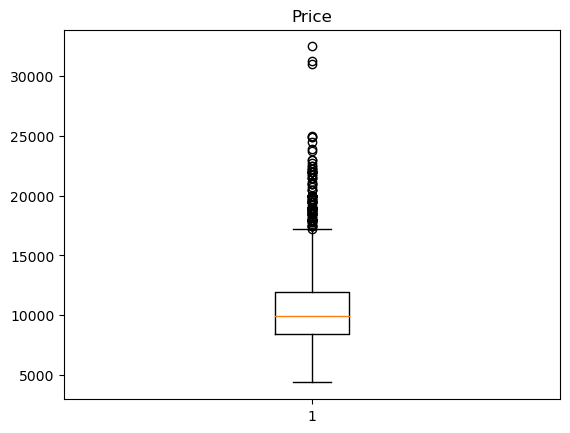

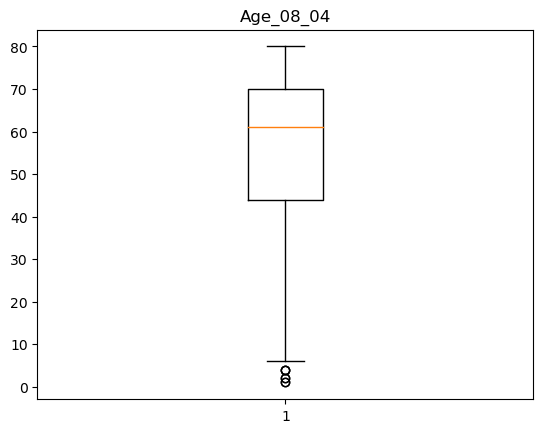

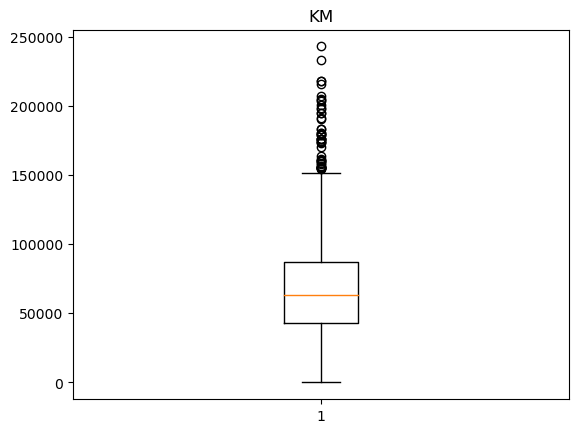

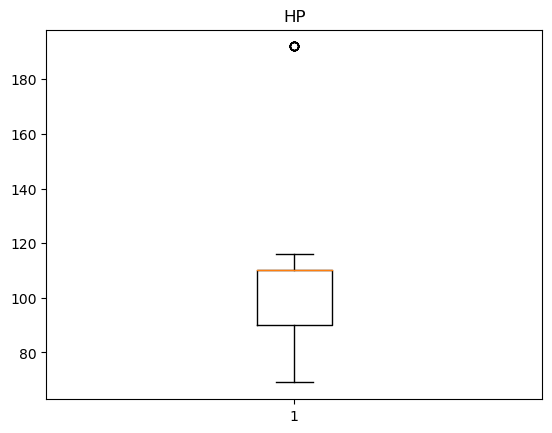

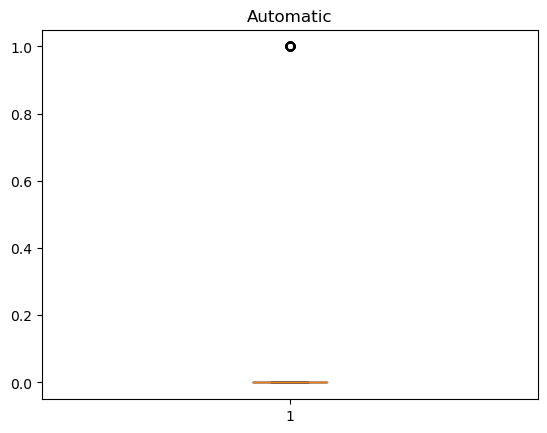

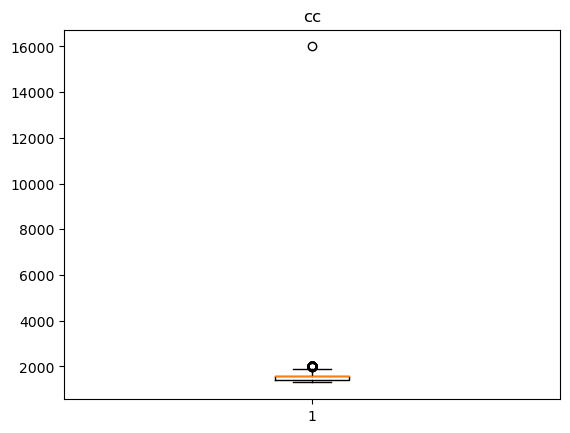

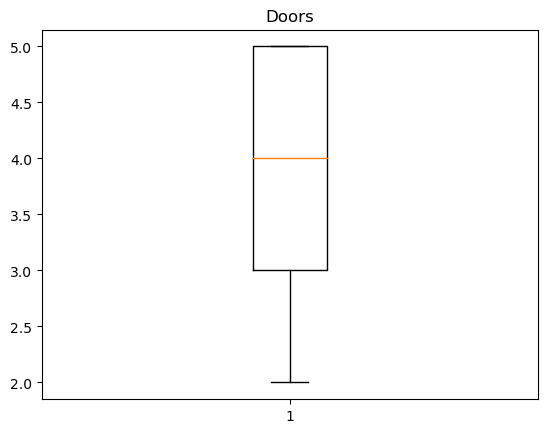

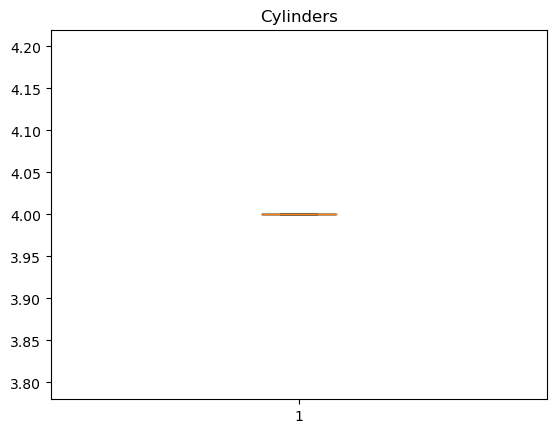

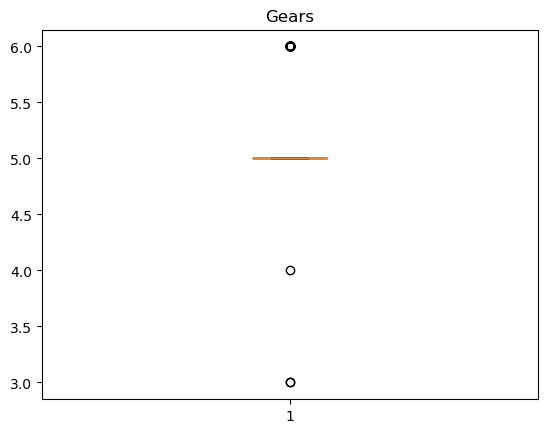

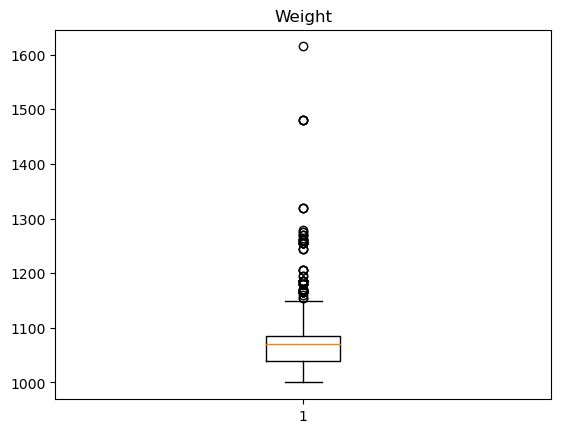

In [5]:
# Identifying the outliers

num = df.select_dtypes(include='number')

for i in num.columns:
    plt.boxplot(num[i])
    plt.title(i)
    plt.show()

In [6]:
Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
IQR = Q3 - Q1

print('IQR for each numeric column')
IQR

IQR for each numeric column


Price         3500.00
Age_08_04       26.00
KM           44020.75
HP              20.00
Automatic        0.00
cc             200.00
Doors            2.00
Cylinders        0.00
Gears            0.00
Weight          45.00
dtype: float64

In [7]:
UE = Q3 + 1.5*IQR

LE = Q1 - 1.5*IQR

In [8]:
# Identify outliers
outliers = ((num < LE) | 
            (num > UE))

print('No. of outliers per column:')
print(outliers.sum())

No. of outliers per column:
Price        110
Age_08_04      7
KM            49
HP            11
Automatic     80
cc           123
Doors          0
Cylinders      0
Gears         46
Weight        66
dtype: int64


In [9]:
# Treating Outliers

for col in num.columns:
    num.loc[num[col] < LE[col],col]=LE[col]
    num.loc[num[col] > UE[col], col]=UE[col]

In [10]:
# Identify outliers
outliers = ((num < LE) | 
            (num > UE))

print('No. of outliers per column:')
print(outliers.sum())

No. of outliers per column:
Price        0
Age_08_04    0
KM           0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [11]:
df_cleaned = pd.concat([df.select_dtypes(exclude='number'), num], axis=1)
df_cleaned

,Fuel_Type,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,Diesel,13500,23,46986.0,90,0,1900,3,4,5,1152.5
1,Diesel,13750,23,72937.0,90,0,1900,3,4,5,1152.5
2,Diesel,13950,24,41711.0,90,0,1900,3,4,5,1152.5
3,Diesel,14950,26,48000.0,90,0,1900,3,4,5,1152.5
4,Diesel,13750,30,38500.0,90,0,1900,3,4,5,1152.5
...,...,...,...,...,...,...,...,...,...,...,...
1431,Petrol,7500,69,20544.0,86,0,1300,3,4,5,1025.0
1432,Petrol,10845,72,19000.0,86,0,1300,3,4,5,1015.0
1433,Petrol,8500,71,17016.0,86,0,1300,3,4,5,1015.0
1434,Petrol,7250,70,16916.0,86,0,1300,3,4,5,1015.0


In [12]:
# Statistics of Numerical Variables
df_cleaned.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.00000,1436.0,1436.000000,1436.000000,1436.0,1436.0,1436.000000
mean,10500.633008,55.958914,67604.873172,101.10376,0.0,1558.565460,4.033426,4.0,5.0,1068.579387
std,2981.813672,18.566512,34738.595454,13.14745,0.0,168.970222,0.952677,0.0,0.0,37.774625
min,4350.000000,5.000000,1.000000,69.00000,0.0,1300.000000,2.000000,4.0,5.0,1000.000000
25%,8450.000000,44.000000,43000.000000,90.00000,0.0,1400.000000,3.000000,4.0,5.0,1040.000000
50%,9900.000000,61.000000,63389.500000,110.00000,0.0,1600.000000,4.000000,4.0,5.0,1070.000000
75%,11950.000000,70.000000,87020.750000,110.00000,0.0,1600.000000,5.000000,4.0,5.0,1085.000000
max,17200.000000,80.000000,153051.875000,140.00000,0.0,1900.000000,5.000000,4.0,5.0,1152.500000


In [13]:
df_cleaned['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_cleaned['Fuel_Type'] = le.fit_transform(df_cleaned['Fuel_Type'])

In [15]:
df_cleaned['Fuel_Type'].unique()

array([1, 2, 0])

In [16]:
df_cleaned.head()

,Fuel_Type,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,1,13500,23,46986.0,90,0,1900,3,4,5,1152.5
1,1,13750,23,72937.0,90,0,1900,3,4,5,1152.5
2,1,13950,24,41711.0,90,0,1900,3,4,5,1152.5
3,1,14950,26,48000.0,90,0,1900,3,4,5,1152.5
4,1,13750,30,38500.0,90,0,1900,3,4,5,1152.5


In [17]:
import warnings
warnings.filterwarnings('ignore')

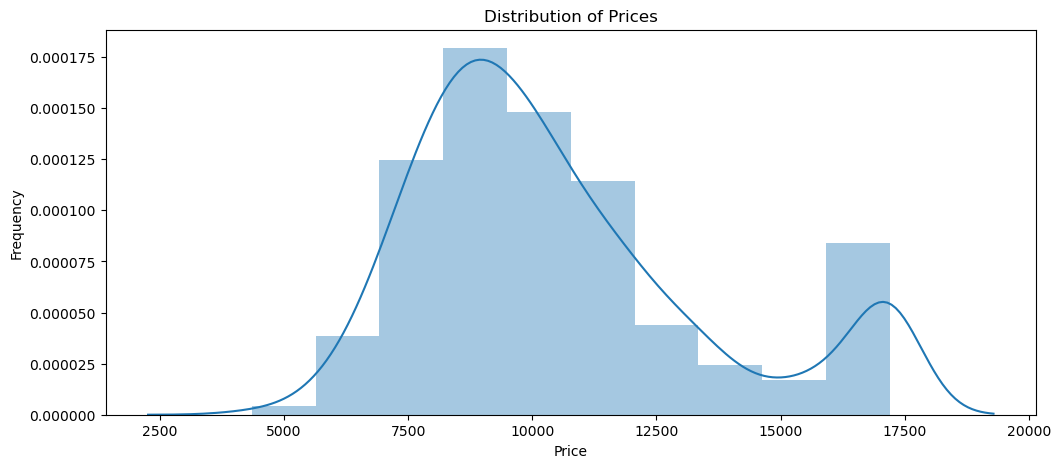

In [18]:
# Distribution of Price

plt.figure(figsize=(12,5))
sns.distplot(df_cleaned['Price'], kde=True,bins=10)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices')
plt.show();

The price distribution is right-skewed, indicating more mid-range priced cars and fewer high-priced vehicles

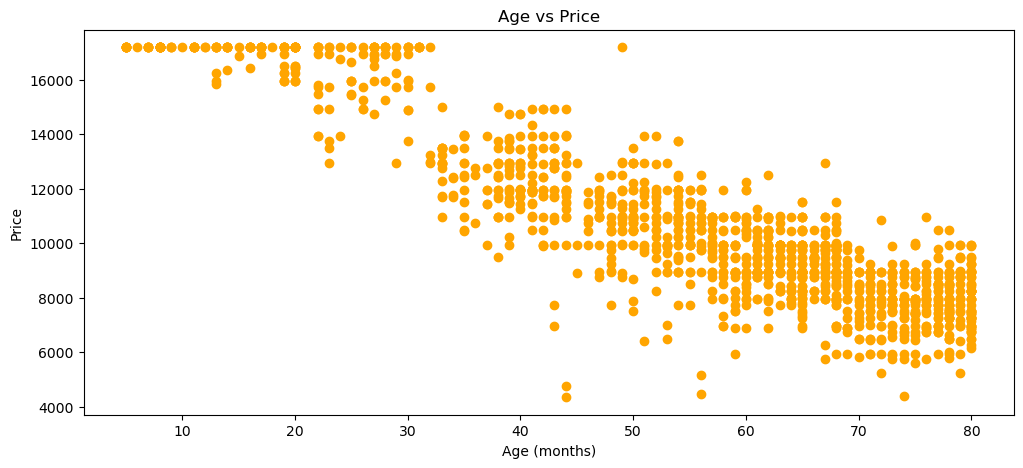

In [19]:
# Age vs Price

plt.figure(figsize=(12,5))
plt.scatter(df_cleaned['Age_08_04'], df_cleaned['Price'],c='orange')
plt.xlabel('Age (months)')
plt.ylabel('Price')
plt.title('Age vs Price')
plt.show()

There is a clear negative relationship between age and price — older cars tend to have lower prices.

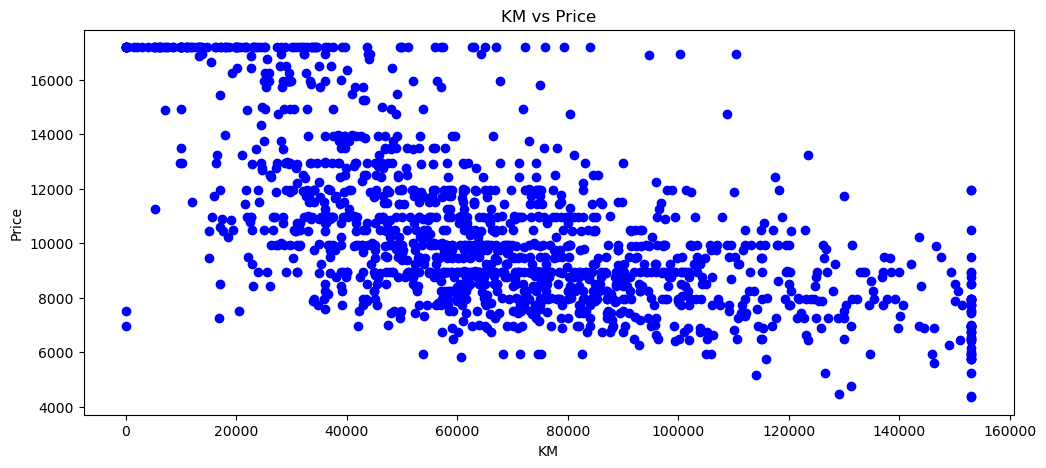

In [20]:
# KM vs Price

plt.figure(figsize=(12,5))
plt.scatter(df_cleaned['KM'], df_cleaned['Price'], c='blue')
plt.xlabel('KM')
plt.ylabel('Price')
plt.title('KM vs Price')
plt.show()

As accumulated kilometers increase, car price generally decreases, showing depreciation with usage.

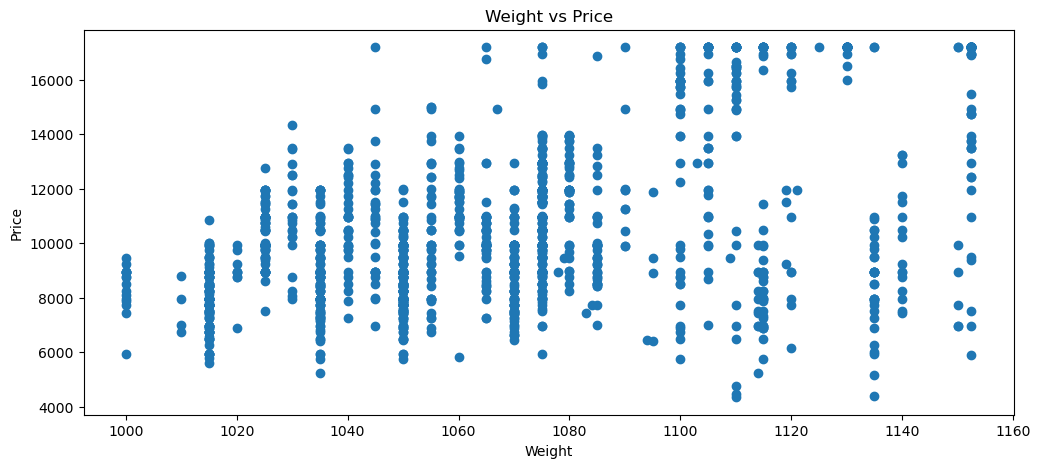

In [21]:
# Weight vs Price

plt.figure(figsize=(12,5))
plt.scatter(df_cleaned['Weight'], df_cleaned['Price'])
plt.xlabel('Weight')
plt.ylabel('Price')
plt.title('Weight vs Price')
plt.show()

Vehicle weight shows a positive correlation with price, indicating heavier cars are usually more expensive.

<Figure size 1200x500 with 0 Axes>

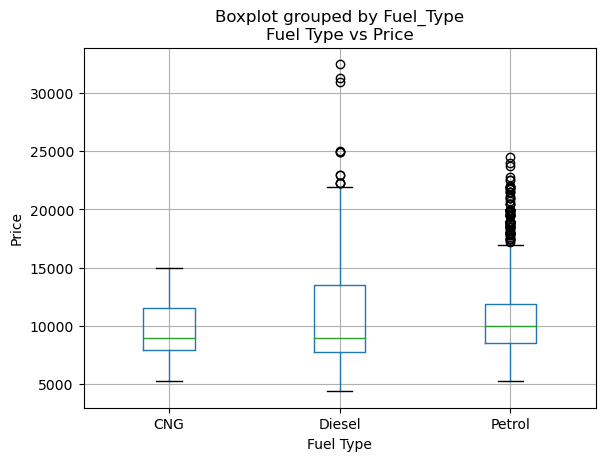

In [22]:
plt.figure(figsize=(12,5))
df.boxplot(column='Price', by='Fuel_Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Fuel Type vs Price')
plt.show();

Diesel vehicles generally have higher median prices compared to Petrol and CNG.

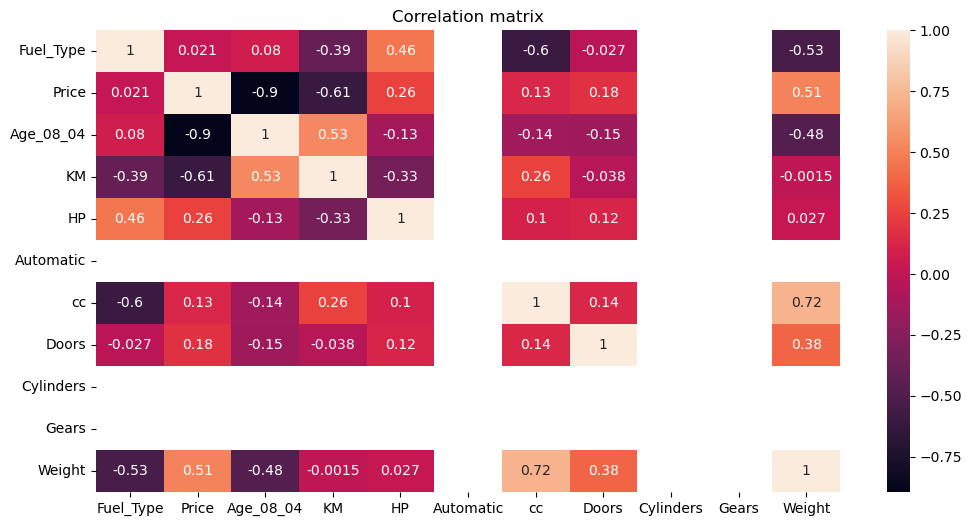

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(df_cleaned.corr(), annot=True)
plt.title('Correlation matrix')
plt.show()

The exploratory data analysis shows that Age, KM, HP, Weight, and Fuel_Type are important factors influencing the price of Toyota Corolla cars. The dataset is clean, contains no missing values,no outliers and exhibits meaningful relationships between predictors and the target variable.

**2) Split the dataset into training and testing sets (e.g., 80% training, 20% testing).**

In [24]:
X = df_cleaned.drop('Price', axis=1)
y = df_cleaned['Price']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 10), (288, 10), (1148,), (288,))

The dataset was split into training and testing sets using an 80:20 ratio. The training set is used to build the multiple linear regression model, while the testing set is used to evaluate its predictive performance on unseen data.

**3) Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.**

In [27]:
# Model 1: Full Model (All Predictors)

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

LinearRegression()

In [28]:
coefficients_1 = pd.DataFrame({'Feature':X_train.columns, 'Coefficent':model_1.coef_})

coefficients_1

,Feature,Coefficent
0,Fuel_Type,5.991301e+02
1,Age_08_04,-1.068513e+02
2,KM,-1.444876e-02
3,HP,1.938407e+01
4,Automatic,1.634248e-13
5,cc,-1.835443e+00
6,Doors,-1.009452e+02
7,Cylinders,0.000000e+00
8,Gears,0.000000e+00
9,Weight,2.513759e+01


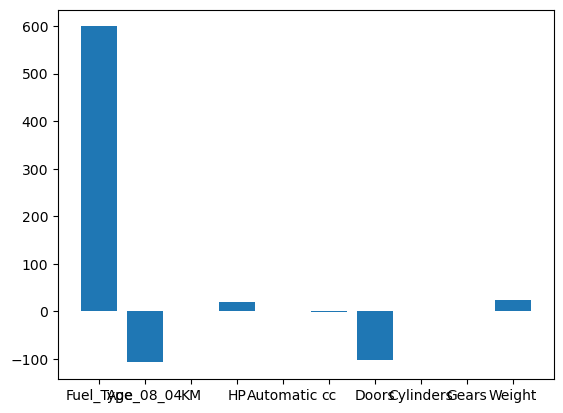

In [29]:
plt.bar(x='Feature', height='Coefficent', data=coefficients_1);

In [30]:
# Model 2: Reduced Model

selected_features = ['Age_08_04', 'KM','HP','Weight','Fuel_Type']

X_train_m2 = X_train[selected_features]
X_test_m2 = X_test[selected_features]

model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [31]:
coefficients_2 = pd.DataFrame({'Feature':X_train_m2.columns, 'Coefficient':model_2.coef_})

coefficients_2

,Feature,Coefficient
0,Age_08_04,-109.612070
1,KM,-0.015749
2,HP,12.191975
3,Weight,18.893952
4,Fuel_Type,820.667655


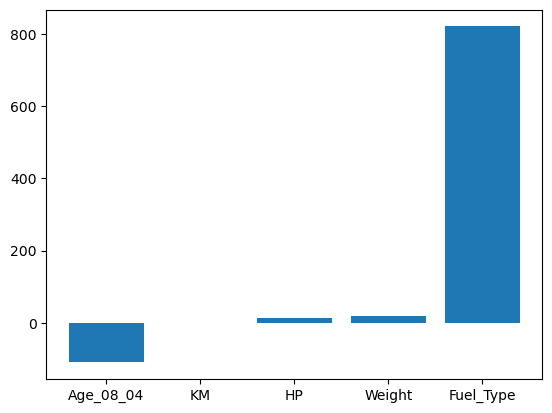

In [32]:
plt.bar(x='Feature', height='Coefficient', data=coefficients_2);

In [33]:
# Model 3: Engine Focused

engine_features = ['HP','cc','Cylinders','Gears','Automatic','Weight','Fuel_Type']

X_train_m3 = X_train[engine_features]
X_test_m3 = X_test[engine_features]

model_3 =  LinearRegression()
model_3.fit(X_train_m3, y_train)

LinearRegression()

In [34]:
coefficients_3 = pd.DataFrame({'Feature':X_train_m3.columns, 'Coefficient':model_3.coef_})

coefficients_3

,Feature,Coefficient
0,HP,5.088284e+01
1,cc,-8.269405e+00
2,Cylinders,4.632739e-12
3,Gears,0.000000e+00
4,Automatic,0.000000e+00
5,Weight,7.229274e+01
6,Fuel_Type,1.103586e+03


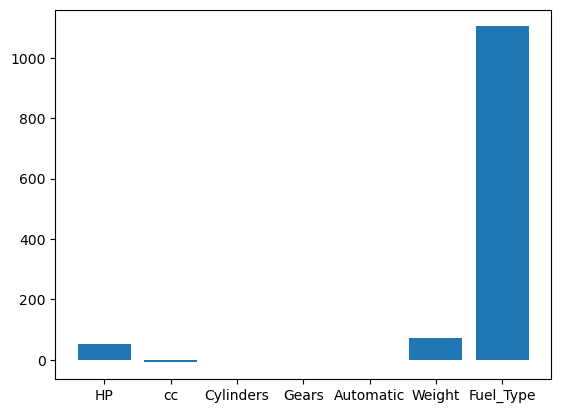

In [35]:
plt.bar(x='Feature', height='Coefficient', data=coefficients_3);

Three multiple linear regression models were developed to predict Toyota Corolla prices

**4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.**

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [37]:
## Model 1 Evaluation

y_pred_1 = model_1.predict(X_test)

r2_1 = np.round(r2_score(y_test, y_pred_1), 3)
mae_1 = np.round(mean_absolute_error(y_test, y_pred_1),3)
rmse_1 = np.round(np.sqrt(mean_squared_error(y_test, y_pred_1)),3)

print('R2_score for model 1: ',r2_1)
print('Mean Absolute error for model 1: ',mae_1)
print('Root mean Square Error for model 1: ',rmse_1)

R2_score for model 1:  0.863
Mean Absolute error for model 1:  830.379
Root mean Square Error for model 1:  1086.615


In [38]:
## Model 2 Evaluation

y_pred_2 = model_2.predict(X_test_m2)

r2_2 = np.round(r2_score(y_test, y_pred_2), 3)
mae_2 = np.round(mean_absolute_error(y_test, y_pred_2),3)
rmse_2 = np.round(np.sqrt(mean_squared_error(y_test, y_pred_2)),3)

print('R2_score for model 2: ',r2_2)
print('Mean Absolute error for model 2: ',mae_2)
print('Root mean Square Error for model 2: ',rmse_2)

R2_score for model 2:  0.86
Mean Absolute error for model 2:  842.003
Root mean Square Error for model 2:  1098.105


In [39]:
## Model 3 Evaluation

y_pred_3 = model_3.predict(X_test_m3)

r2_3 = np.round(r2_score(y_test, y_pred_3), 3)
mae_3 = np.round(mean_absolute_error(y_test, y_pred_3),3)
rmse_3 = np.round(np.sqrt(mean_squared_error(y_test, y_pred_3)),3)

print('R2_score for model 3: ',r2_3)
print('Mean Absolute error for model 3: ',mae_3)
print('Root mean Square Error for model 3: ',rmse_3)

R2_score for model 3:  0.433
Mean Absolute error for model 3:  1738.159
Root mean Square Error for model 3:  2207.107


The performance of the three multiple linear regression models was evaluated using the testing dataset with R2_score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

The evaluation shows that the full and reduced models perform well with high explanatory power, while the engine-focused model performs poorly, confirming that age and usage factors are essential for accurate car price prediction.

**5) Apply Lasso and Ridge methods on the model.**

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Ridge Regression Model

from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [42]:
# Evaluation

y_pred_ridge = ridge_model.predict(X_test_scaled)

r2_ridge = np.round(r2_score(y_test, y_pred_ridge),3)
mae_ridge = np.round(mean_absolute_error(y_test, y_pred_ridge),3)
rmse_ridge = np.round(np.sqrt(mean_squared_error(y_test, y_pred_ridge)),3)

print('R2_score for ridge model: ',r2_ridge)
print('Mean Absolute error for ridge model: ',mae_ridge)
print('Root mean Square Error for ridge model: ',rmse_ridge)

R2_score for ridge model:  0.863
Mean Absolute error for ridge model:  830.334
Root mean Square Error for ridge model:  1086.641


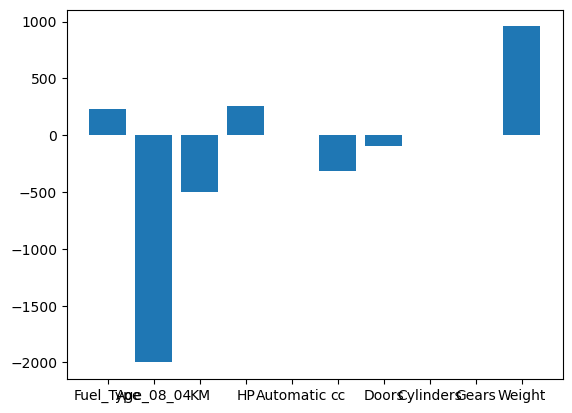

In [43]:
coefficients_ridge = pd.DataFrame({'Feature':X_train.columns, 'Coefficent':ridge_model.coef_})
plt.bar(x='Feature', height='Coefficent', data=coefficients_ridge);

In [44]:
## Lasso Regression Model

from sklearn.linear_model import Lasso

lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)

Lasso()

In [45]:
# Evaluation

y_pred_lasso = lasso_model.predict(X_test_scaled)

r2_lasso = np.round(r2_score(y_test, y_pred_lasso),3)
mae_lasso = np.round(mean_absolute_error(y_test, y_pred_lasso),3)
rmse_lasso = np.round(np.sqrt(mean_squared_error(y_test, y_pred_lasso)),3)

print('R2_score for ridge model: ',r2_lasso)
print('Mean Absolute error for ridge model: ',mae_lasso)
print('Root mean Square Error for ridge model: ',rmse_lasso)

R2_score for ridge model:  0.863
Mean Absolute error for ridge model:  830.37
Root mean Square Error for ridge model:  1086.565


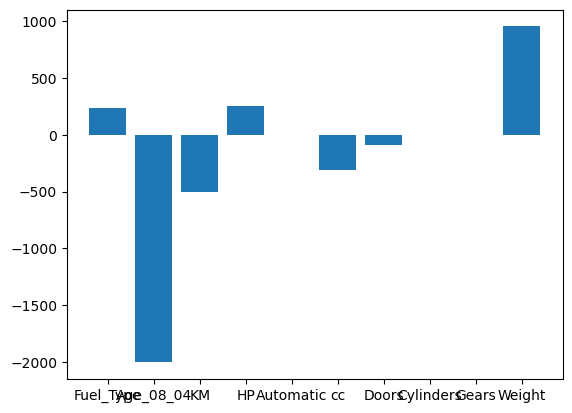

In [46]:
coefficients_lasso = pd.DataFrame({'Feature':X_train.columns, 'Coefficent':lasso_model.coef_})
plt.bar(x='Feature', height='Coefficent', data=coefficients_lasso);

In [47]:
regularization_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [r2_1, r2_ridge, r2_lasso],
    'MAE': [mae_1, mae_ridge, mae_lasso],
    'RMSE': [rmse_1, rmse_ridge, rmse_lasso]
})

regularization_results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.863,830.379,1086.615
1,Ridge Regression,0.863,830.334,1086.641
2,Lasso Regression,0.863,830.370,1086.565


### Interview Questions:

**1. What is Normalization & Standardization and how is it helpful?**

Normalization is a scaling technique that transforms data into a fixed range, usually 0 to 1.
It is useful when features have different units and we want to bring them to the same scale.

Standardization transforms data so that it has a mean of 0 and a standard deviation of 1. It preserves the distribution shape and is commonly used in regression and machine learning models.

Both techniques improve model performance and stability by ensuring that no feature dominates due to its scale. They are especially important for distance-based and regularized models like Ridge and Lasso regression.

**2. What techniques can be used to address multicollinearity in multiple linear regression?**

Multicollinearity occurs when independent variables are highly correlated. It can be addressed using the following techniques:

* Remove highly correlated variables based on correlation matrix or VIF

* Feature selection to keep only important predictors

* Ridge Regression to shrink coefficients and reduce variance

* Lasso Regression to shrink coefficients and perform feature selection

* Increase sample size to reduce instability in coefficient estimates
